In [1]:
import numpy as np
import pandas as pd
import scikit_posthocs as sp
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import FormatStrFormatter

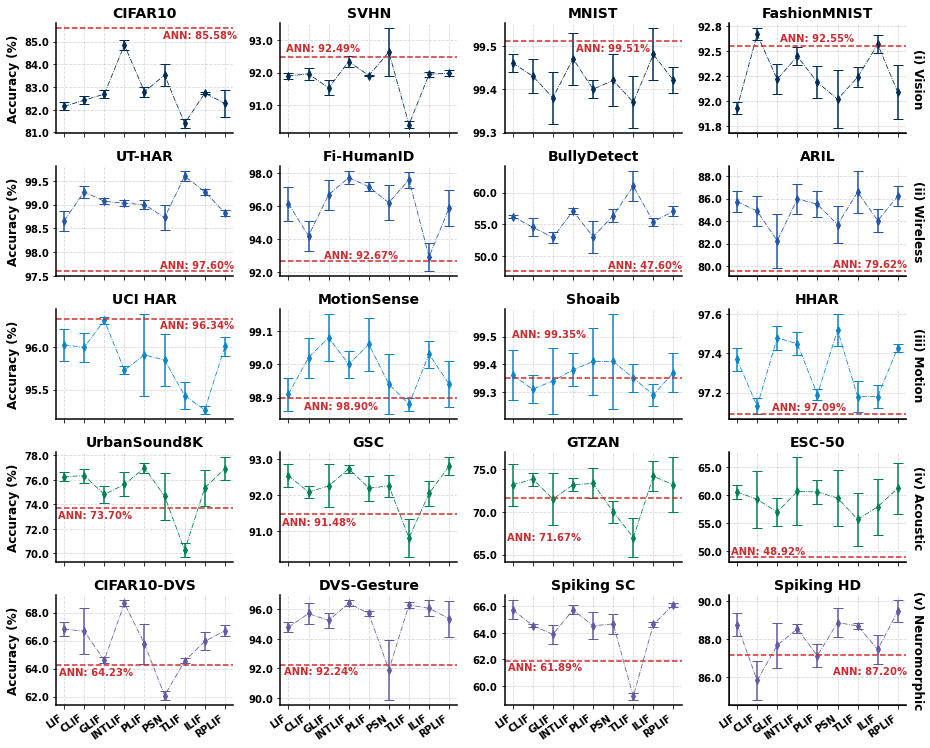

In [3]:
fig, axs = plt.subplots(5, 4, figsize=(13, 10.5))
categories = ['ANN', 'LIF', 'CLIF', 'GLIF', 'INTLIF', 'PLIF', 'PSN', 'TLIF', 'ILIF', 'RPLIF']
x = np.arange(len(categories))

modalities = ['(i) Vision', '(ii) Wireless', '(iii) Motion', '(iv) Acoustic', '(v) Neuromorphic']
modality_colors = ['#002c53', '#007f54', '#0c84c6', '#2455a4', '#625ba1']
for i in range(5):
    for j in range(4):
        if j == 0:
            axs[i][j].set_ylabel('Accuracy (%)', fontweight='bold', fontsize=12)

        if j == 3:
            # define sensing label at right axis
            ax_right = axs[i][j].twinx()
            ax_right.spines['top'].set_visible(False)
            ax_right.spines['right'].set_visible(False)
            ax_right.set_yticks([])
            ax_right.set_ylabel(f'{modalities[i]}', fontweight='bold', fontsize=12, rotation=-90)
            ax_right.yaxis.set_label_coords(1.1, 0.5)

        for label in axs[i][j].get_xticklabels() + axs[i][j].get_yticklabels():
            label.set_fontsize(10)       
            label.set_fontweight('bold')

        for spine in axs[i][j].spines.values():
            spine.set_linewidth(1.5)
        
        axs[i][j].spines['top'].set_visible(False)
        axs[i][j].spines['right'].set_visible(False)
        # axs[i].set_yticks([])
        axs[i][j].grid(True, which='both', linestyle='--', color='gray', alpha=0.3, zorder=0)
        axs[i][j].yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

        # 设置x label，只有最后一层显示
        axs[i][j].set_xticks(x[1:])
        if i == 4:
            axs[i][j].set_xticklabels(categories[1:], rotation=35, ha='right')
            # for idx, tick in enumerate(axs[i][j].get_xticklabels()):
            #     if idx == 0:
            #         tick.set_color('#c82d31')
            #     else:
            #         tick.set_color('#194f97')
        else:
            axs[i][j].set_xticklabels([])

# (a) vision sensing
line_color = modality_colors[0]
# cifar10
axs[0][0].set_title('CIFAR10', fontweight='bold', fontsize=14)
mean_accs = [85.58, 82.15, 82.42, 82.69, 84.85, 82.79, 83.53, 81.40, 82.73, 82.28]
std_accs = [0.17, 0.17, 0.18, 0.18, 0.21, 0.21, 0.50, 0.21, 0.05, 0.58]
axs[0][0].plot(x[1:], mean_accs[1:], 'd-.', color=line_color, linewidth=0.8, markersize=5)
axs[0][0].errorbar(x[1:], mean_accs[1:], yerr=std_accs[1:], fmt='none', ecolor=line_color, elinewidth=1.5, capsize=5)
axs[0][0].axhline(y=mean_accs[0], color='#c82d31', linestyle='--', linewidth=1.5)
axs[0][0].text(len(categories) - 0.4, mean_accs[0] - 0.1, f'ANN: {mean_accs[0]:.2f}%', 
               color='#c82d31', fontsize=10, fontweight='bold', ha='right', va='top')

# svhn
axs[0][1].set_title('SVHN', fontweight='bold', fontsize=14)
mean_accs = [92.49, 91.90, 91.96, 91.53, 92.34, 91.91, 92.63, 90.40, 91.95, 91.98]
std_accs = [0.18, 0.09, 0.19, 0.23, 0.17, 0.03, 0.73, 0.11, 0.08, 0.09]
axs[0][1].plot(x[1:], mean_accs[1:], 'd-.', color=line_color, linewidth=0.8, markersize=5)
axs[0][1].errorbar(x[1:], mean_accs[1:], yerr=std_accs[1:], fmt='none', ecolor=line_color, elinewidth=1.5, capsize=5)
axs[0][1].axhline(y=mean_accs[0], color='#c82d31', linestyle='--', linewidth=1.5)
axs[0][1].text(len(categories[0]) - 0.3, mean_accs[0] + 0.1, f'ANN: {mean_accs[0]:.2f}%', 
               color='#c82d31', fontsize=10, fontweight='bold', ha='center', va='bottom')

# mnist
axs[0][2].set_title('MNIST', fontweight='bold', fontsize=14)
mean_accs = [99.51, 99.46, 99.43, 99.38, 99.47, 99.40, 99.42, 99.37, 99.48, 99.42]
std_accs = [0.04, 0.02, 0.04, 0.06, 0.06, 0.02, 0.06, 0.06, 0.06, 0.03]
axs[0][2].plot(x[1:], mean_accs[1:], 'd-.', color=line_color, linewidth=0.8, markersize=5)
axs[0][2].errorbar(x[1:], mean_accs[1:], yerr=std_accs[1:], fmt='none', ecolor=line_color, elinewidth=1.5, capsize=5)
axs[0][2].axhline(y=mean_accs[0], color='#c82d31', linestyle='--', linewidth=1.5)
axs[0][2].text(6, mean_accs[0] - 0.005, f'ANN: {mean_accs[0]:.2f}%', 
               color='#c82d31', fontsize=10, fontweight='bold', ha='center', va='top')

# fashionmnist
axs[0][3].set_title('FashionMNIST', fontweight='bold', fontsize=14)
mean_accs = [92.55, 91.93, 92.67, 92.22, 92.45, 92.19, 92.02, 92.24, 92.57, 92.09]
std_accs = [0.11, 0.06, 0.06, 0.15, 0.09, 0.16, 0.29, 0.10, 0.09, 0.27]
axs[0][3].plot(x[1:], mean_accs[1:], 'd-.', color=line_color, linewidth=0.8, markersize=5)
axs[0][3].errorbar(x[1:], mean_accs[1:], yerr=std_accs[1:], fmt='none', ecolor=line_color, elinewidth=1.5, capsize=5)
axs[0][3].axhline(y=mean_accs[0], color='#c82d31', linestyle='--', linewidth=1.5)
axs[0][3].text(5, mean_accs[0] + 0.03, f'ANN: {mean_accs[0]:.2f}%', 
               color='#c82d31', fontsize=10, fontweight='bold', ha='center', va='bottom')

# (d) Acoustic Sensing
line_color = modality_colors[1]
# urbansound
axs[3][0].set_title('UrbanSound8K', fontweight='bold', fontsize=14)
mean_accs = [73.70, 76.25, 76.34, 74.81, 75.62, 76.97, 74.67, 70.26, 75.34, 76.91]
std_accs = [1.18, 0.37, 0.58, 0.68, 0.98, 0.43, 1.91, 0.56, 1.47, 0.92]
axs[3][0].plot(x[1:], mean_accs[1:], 'd-.', color=line_color, linewidth=0.8, markersize=5)
axs[3][0].errorbar(x[1:], mean_accs[1:], yerr=std_accs[1:], fmt='none', ecolor=line_color, elinewidth=1.5, capsize=5)
axs[3][0].axhline(y=mean_accs[0], color='#c82d31', linestyle='--', linewidth=1.5)
axs[3][0].text(0.7, mean_accs[0] - 0.15, f'ANN: {mean_accs[0]:.2f}%', 
               color='#c82d31', fontsize=10, fontweight='bold', ha='left', va='top')

# GSC
axs[3][1].set_title('GSC', fontweight='bold', fontsize=14)
mean_accs = [91.48, 92.55, 92.09, 92.26, 92.74, 92.20, 92.26, 90.81, 92.05, 92.82]
std_accs = [0.16, 0.31, 0.17, 0.6, 0.11, 0.35, 0.30, 0.54, 0.35, 0.24]
axs[3][1].plot(x[1:], mean_accs[1:], 'd-.', color=line_color, linewidth=0.8, markersize=5)
axs[3][1].errorbar(x[1:], mean_accs[1:], yerr=std_accs[1:], fmt='none', ecolor=line_color, elinewidth=1.5, capsize=5)
axs[3][1].axhline(y=mean_accs[0], color='#c82d31', linestyle='--', linewidth=1.5)
axs[3][1].text(0.7, mean_accs[0] - 0.1, f'ANN: {mean_accs[0]:.2f}%', 
               color='#c82d31', fontsize=10, fontweight='bold', ha='left', va='top')

# GTZAN
axs[3][2].set_title('GTZAN', fontweight='bold', fontsize=14)
mean_accs = [71.67, 73.17, 73.83, 71.50, 73.17, 73.33, 70, 67, 74.17, 73.17]
std_accs = [1.61, 2.47, 0.76, 3.04, 0.76, 1.76, 1.32, 2.29, 1.76, 3.21]
axs[3][2].plot(x[1:], mean_accs[1:], 'd-.', color=line_color, linewidth=0.8, markersize=5)
axs[3][2].errorbar(x[1:], mean_accs[1:], yerr=std_accs[1:], fmt='none', ecolor=line_color, elinewidth=1.5, capsize=5)
axs[3][2].axhline(y=mean_accs[0], color='#c82d31', linestyle='--', linewidth=1.5)
axs[3][2].text(0.7, mean_accs[0] - 4, f'ANN: {mean_accs[0]:.2f}%', 
               color='#c82d31', fontsize=10, fontweight='bold', ha='left', va='top')

# esc50
axs[3][3].set_title('ESC-50', fontweight='bold', fontsize=14)
mean_accs = [48.92, 60.58, 59.25, 57, 60.67, 60.58, 59.50, 55.67, 57.92, 61.25]
std_accs = [3.96, 1.18, 5.07, 2.46, 6.09, 2.13, 5.00, 4.77, 4.96, 4.55]
axs[3][3].plot(x[1:], mean_accs[1:], 'd-.', color=line_color, linewidth=0.8, markersize=5)
axs[3][3].errorbar(x[1:], mean_accs[1:], yerr=std_accs[1:], fmt='none', ecolor=line_color, elinewidth=1.5, capsize=5)
axs[3][3].axhline(y=mean_accs[0], color='#c82d31', linestyle='--', linewidth=1.5)
axs[3][3].text(0.7, mean_accs[0] + 0.2, f'ANN: {mean_accs[0]:.2f}%', 
               color='#c82d31', fontsize=10, fontweight='bold', ha='left', va='bottom')

# (c) Motion Sensing
line_color = modality_colors[2]
# UCI HAR
axs[2][0].set_title('UCI HAR', fontweight='bold', fontsize=14)
mean_accs = [96.34, 96.03, 96, 96.32, 95.73, 95.91, 95.85, 95.43, 95.26, 96.01]
std_accs = [0.19, 0.19, 0.17, 0.04, 0.05, 0.48, 0.31, 0.16, 0.05, 0.11]
axs[2][0].plot(x[1:], mean_accs[1:], 'd-.', color=line_color, linewidth=0.8, markersize=5)
axs[2][0].errorbar(x[1:], mean_accs[1:], yerr=std_accs[1:], fmt='none', ecolor=line_color, elinewidth=1.5, capsize=5)
axs[2][0].axhline(y=mean_accs[0], color='#c82d31', linestyle='--', linewidth=1.5)
axs[2][0].text(7.6, mean_accs[0] - 0.02, f'ANN: {mean_accs[0]:.2f}%', 
               color='#c82d31', fontsize=10, fontweight='bold', ha='center', va='top')

# MotionSense
axs[2][1].set_title('MotionSense', fontweight='bold', fontsize=14)
mean_accs = [98.90, 98.91, 99.02, 99.08, 99, 99.06, 98.94, 98.88, 99.03, 98.94]
std_accs = [0.05, 0.05, 0.06, 0.07, 0.04, 0.08, 0.09, 0.02, 0.04, 0.07]
axs[2][1].plot(x[1:], mean_accs[1:], 'd-.', color=line_color, linewidth=0.8, markersize=5)
axs[2][1].errorbar(x[1:], mean_accs[1:], yerr=std_accs[1:], fmt='none', ecolor=line_color, elinewidth=1.5, capsize=5)
axs[2][1].axhline(y=mean_accs[0], color='#c82d31', linestyle='--', linewidth=1.5)
axs[2][1].text(3.6, mean_accs[0] - 0.01, f'ANN: {mean_accs[0]:.2f}%', 
               color='#c82d31', fontsize=10, fontweight='bold', ha='center', va='top')

# Shoaib
axs[2][2].set_title('Shoaib', fontweight='bold', fontsize=14)
mean_accs = [99.35, 99.36, 99.31, 99.34, 99.38, 99.41, 99.41, 99.35, 99.29, 99.37]
std_accs = [0.02, 0.09, 0.05, 0.12, 0.06, 0.12, 0.17, 0.05, 0.04, 0.07]
axs[2][2].plot(x[1:], mean_accs[1:], 'd-.', color=line_color, linewidth=0.8, markersize=5)
axs[2][2].errorbar(x[1:], mean_accs[1:], yerr=std_accs[1:], fmt='none', ecolor=line_color, elinewidth=1.5, capsize=5)
axs[2][2].axhline(y=mean_accs[0], color='#c82d31', linestyle='--', linewidth=1.5)
axs[2][2].text(2.8, mean_accs[0] + 0.14, f'ANN: {mean_accs[0]:.2f}%', 
               color='#c82d31', fontsize=10, fontweight='bold', ha='center', va='bottom')

# HHAR
axs[2][3].set_title('HHAR', fontweight='bold', fontsize=14)
mean_accs = [97.09, 97.37, 97.13, 97.48, 97.45, 97.19, 97.52, 97.18, 97.18, 97.43]
std_accs = [0.04, 0.06, 0.04, 0.06, 0.06, 0.03, 0.08, 0.08, 0.06, 0.02]
axs[2][3].plot(x[1:], mean_accs[1:], 'd-.', color=line_color, linewidth=0.8, markersize=5)
axs[2][3].errorbar(x[1:], mean_accs[1:], yerr=std_accs[1:], fmt='none', ecolor=line_color, elinewidth=1.5, capsize=5)
axs[2][3].axhline(y=mean_accs[0], color='#c82d31', linestyle='--', linewidth=1.5)
axs[2][3].text(4.6, mean_accs[0] + 0.01, f'ANN: {mean_accs[0]:.2f}%', 
               color='#c82d31', fontsize=10, fontweight='bold', ha='center', va='bottom')

# (b) Wireless Sensing
line_color = modality_colors[3]
# UT-HAR
axs[1][0].set_title('UT-HAR', fontweight='bold', fontsize=14)
mean_accs = [97.60, 98.66, 99.27, 99.07, 99.03, 99, 98.73, 99.60, 99.27, 98.83]
std_accs = [0.34, 0.21, 0.12, 0.06, 0.06, 0.10, 0.26, 0.10, 0.06, 0.06]
axs[1][0].plot(x[1:], mean_accs[1:], 'd-.', color=line_color, linewidth=0.8, markersize=5)
axs[1][0].errorbar(x[1:], mean_accs[1:], yerr=std_accs[1:], fmt='none', ecolor=line_color, elinewidth=1.5, capsize=5)
axs[1][0].axhline(y=mean_accs[0], color='#c82d31', linestyle='--', linewidth=1.5)
axs[1][0].text(7.6, mean_accs[0] + 0.01, f'ANN: {mean_accs[0]:.2f}%', 
               color='#c82d31', fontsize=10, fontweight='bold', ha='center', va='bottom')

# NTU-Fi-HumanID
axs[1][1].set_title('Fi-HumanID', fontweight='bold', fontsize=14)
mean_accs = [92.67, 96.15, 94.20, 96.70, 97.74, 97.19, 96.21, 97.62, 92.92, 95.91]
std_accs = [2.16, 1.02, 0.92, 0.92, 0.38, 0.28, 1.06, 0.49, 0.87, 1.10]
axs[1][1].plot(x[1:], mean_accs[1:], 'd-.', color=line_color, linewidth=0.8, markersize=5)
axs[1][1].errorbar(x[1:], mean_accs[1:], yerr=std_accs[1:], fmt='none', ecolor=line_color, elinewidth=1.5, capsize=5)
axs[1][1].axhline(y=mean_accs[0], color='#c82d31', linestyle='--', linewidth=1.5)
axs[1][1].text(4.6, mean_accs[0] + 0.03, f'ANN: {mean_accs[0]:.2f}%', 
               color='#c82d31', fontsize=10, fontweight='bold', ha='center', va='bottom')

# BullyDetect
axs[1][2].set_title('BullyDetect', fontweight='bold', fontsize=14)
mean_accs = [47.60, 56.22, 54.53, 52.92, 57.10, 53.03, 56.38, 61.01, 55.39, 57.10]
std_accs = [1.90, 0.30, 1.40, 0.87, 0.47, 2.55, 1.07, 2.35, 0.59, 0.74]
axs[1][2].plot(x[1:], mean_accs[1:], 'd-.', color=line_color, linewidth=0.8, markersize=5)
axs[1][2].errorbar(x[1:], mean_accs[1:], yerr=std_accs[1:], fmt='none', ecolor=line_color, elinewidth=1.5, capsize=5)
axs[1][2].axhline(y=mean_accs[0], color='#c82d31', linestyle='--', linewidth=1.5)
axs[1][2].text(7.6, mean_accs[0] + 0.1, f'ANN: {mean_accs[0]:.2f}%', 
               color='#c82d31', fontsize=10, fontweight='bold', ha='center', va='bottom')

# ARIL
axs[1][3].set_title('ARIL', fontweight='bold', fontsize=14)
mean_accs = [79.62, 85.73, 84.89, 82.25, 85.97, 85.49, 83.69, 86.57, 84.05, 86.21]
std_accs = [2.39, 0.91, 1.30, 2.39, 1.30, 1.16, 1.62, 1.85, 1.04, 0.91]
axs[1][3].plot(x[1:], mean_accs[1:], 'd-.', color=line_color, linewidth=0.8, markersize=5)
axs[1][3].errorbar(x[1:], mean_accs[1:], yerr=std_accs[1:], fmt='none', ecolor=line_color, elinewidth=1.5, capsize=5)
axs[1][3].axhline(y=mean_accs[0], color='#c82d31', linestyle='--', linewidth=1.5)
axs[1][3].text(7.6, mean_accs[0] + 0.1, f'ANN: {mean_accs[0]:.2f}%', 
               color='#c82d31', fontsize=10, fontweight='bold', ha='center', va='bottom')
axs[1][3].set_ylim(mean_accs[0] - 0.5)

# (e) Neuromorphic Sensing
line_color = modality_colors[4]
# cifar10dvs
axs[4][0].set_title('CIFAR10-DVS', fontweight='bold', fontsize=14)
mean_accs = [64.23, 66.83, 66.67, 64.60, 68.67, 65.77, 62.07, 64.55, 65.95, 66.70]
std_accs = [0.68, 0.51, 1.64, 0.23, 0.21, 1.41, 0.32, 0.18, 0.65, 0.40]
axs[4][0].plot(x[1:], mean_accs[1:], 'd-.', color=line_color, linewidth=0.8, markersize=5)
axs[4][0].errorbar(x[1:], mean_accs[1:], yerr=std_accs[1:], fmt='none', ecolor=line_color, elinewidth=1.5, capsize=5)
axs[4][0].axhline(y=mean_accs[0], color='#c82d31', linestyle='--', linewidth=1.5)
axs[4][0].text(2.6, mean_accs[0] - 0.1, f'ANN: {mean_accs[0]:.2f}%', 
               color='#c82d31', fontsize=10, fontweight='bold', ha='center', va='top')

# dvs-gesture
axs[4][1].set_title('DVS-Gesture', fontweight='bold', fontsize=14)
mean_accs = [92.24, 94.79, 95.72, 95.25, 96.41, 95.72, 91.90, 96.30, 96.07, 95.37]
std_accs = [1.06, 0.35, 0.72, 0.53, 0.20, 0.20, 2.04, 0.20, 0.53, 1.22]
axs[4][1].plot(x[1:], mean_accs[1:], 'd-.', color=line_color, linewidth=0.8, markersize=5)
axs[4][1].errorbar(x[1:], mean_accs[1:], yerr=std_accs[1:], fmt='none', ecolor=line_color, elinewidth=1.5, capsize=5)
axs[4][1].axhline(y=mean_accs[0], color='#c82d31', linestyle='--', linewidth=1.5)
axs[4][1].text(2.6, mean_accs[0] - 0.1, f'ANN: {mean_accs[0]:.2f}%', 
               color='#c82d31', fontsize=10, fontweight='bold', ha='center', va='top')

# ssc
axs[4][2].set_title('Spiking SC', fontweight='bold', fontsize=14)
mean_accs = [61.89, 65.75, 64.55, 63.89, 65.74, 64.54, 64.68, 59.21, 64.66, 66.11]
std_accs = [1.26, 0.71, 0.12, 0.70, 0.33, 1.02, 0.75, 0.28, 0.19, 0.14]
axs[4][2].plot(x[1:], mean_accs[1:], 'd-.', color=line_color, linewidth=0.8, markersize=5)
axs[4][2].errorbar(x[1:], mean_accs[1:], yerr=std_accs[1:], fmt='none', ecolor=line_color, elinewidth=1.5, capsize=5)
axs[4][2].axhline(y=mean_accs[0], color='#c82d31', linestyle='--', linewidth=1.5)
axs[4][2].text(2.6, mean_accs[0] - 0.1, f'ANN: {mean_accs[0]:.2f}%', 
               color='#c82d31', fontsize=10, fontweight='bold', ha='center', va='top')

# shd
axs[4][3].set_title('Spiking HD', fontweight='bold', fontsize=14)
mean_accs = [87.20, 88.78, 85.84, 87.69, 88.55, 87.14, 88.88, 88.71, 87.47, 89.48]
std_accs = [0.42, 0.62, 1.03, 1.19, 0.24, 0.60, 0.75, 0.14, 0.78, 0.57]
axs[4][3].plot(x[1:], mean_accs[1:], 'd-.', color=line_color, linewidth=0.8, markersize=5)
axs[4][3].errorbar(x[1:], mean_accs[1:], yerr=std_accs[1:], fmt='none', ecolor=line_color, elinewidth=1.5, capsize=5)
axs[4][3].axhline(y=mean_accs[0], color='#c82d31', linestyle='--', linewidth=1.5)
axs[4][3].text(7.6, mean_accs[0] - 0.6, f'ANN: {mean_accs[0]:.2f}%', 
               color='#c82d31', fontsize=10, fontweight='bold', ha='center', va='top')

fig.tight_layout()
plt.savefig('./cmp-lif-sensing.pdf', dpi=300, bbox_inches="tight")
plt.show()

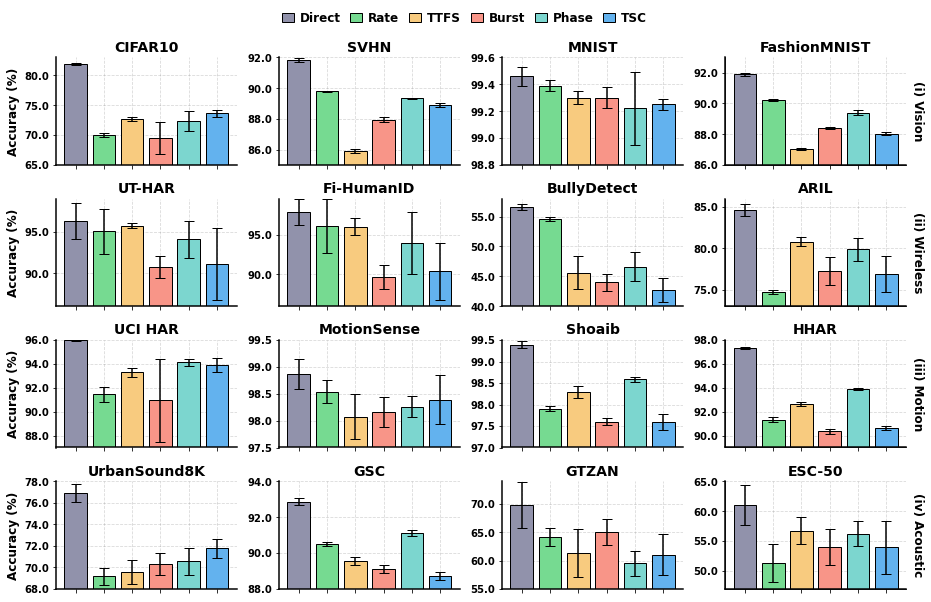

In [3]:
fig, axs = plt.subplots(4, 4, figsize=(13, 8))
categories = ['Direct', 'Rate', 'TTFS', 'Burst', 'Phase', 'TSC']
x = np.arange(len(categories))

modalities = ['(i) Vision', '(ii) Wireless', '(iii) Motion', '(iv) Acoustic']
for i in range(4):
    for j in range(4):
        if j == 0:
            axs[i][j].set_ylabel('Accuracy (%)', fontweight='bold', fontsize=12)

        if j == 3:
            # define sensing label at right axis
            ax_right = axs[i][j].twinx()
            ax_right.spines['top'].set_visible(False)
            ax_right.spines['right'].set_visible(False)
            ax_right.set_yticks([])
            ax_right.set_ylabel(f'{modalities[i]}', fontweight='bold', fontsize=12, rotation=-90)
            ax_right.yaxis.set_label_coords(1.1, 0.5)

        for label in axs[i][j].get_xticklabels() + axs[i][j].get_yticklabels():
            label.set_fontsize(10)       
            label.set_fontweight('bold')

        for spine in axs[i][j].spines.values():
            spine.set_linewidth(1.5)
        
        axs[i][j].spines['top'].set_visible(False)
        axs[i][j].spines['right'].set_visible(False)
        # axs[i].set_yticks([])
        axs[i][j].grid(True, which='both', linestyle='--', color='gray', alpha=0.3, zorder=0)
        axs[i][j].yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

        # 设置x label，只有最后一层显示
        axs[i][j].set_xticks(x)
        axs[i][j].set_xticklabels([])

axs[0][0].set_title('CIFAR10', fontweight='bold', fontsize=14)
axs[0][1].set_title('SVHN', fontweight='bold', fontsize=14)
axs[0][2].set_title('MNIST', fontweight='bold', fontsize=14)
axs[0][3].set_title('FashionMNIST', fontweight='bold', fontsize=14)

axs[1][0].set_title('UT-HAR', fontweight='bold', fontsize=14)
axs[1][1].set_title('Fi-HumanID', fontweight='bold', fontsize=14)
axs[1][2].set_title('BullyDetect', fontweight='bold', fontsize=14)
axs[1][3].set_title('ARIL', fontweight='bold', fontsize=14)

axs[2][0].set_title('UCI HAR', fontweight='bold', fontsize=14)
axs[2][1].set_title('MotionSense', fontweight='bold', fontsize=14)
axs[2][2].set_title('Shoaib', fontweight='bold', fontsize=14)
axs[2][3].set_title('HHAR', fontweight='bold', fontsize=14)

axs[3][0].set_title('UrbanSound8K', fontweight='bold', fontsize=14)
axs[3][1].set_title('GSC', fontweight='bold', fontsize=14)
axs[3][2].set_title('GTZAN', fontweight='bold', fontsize=14)
axs[3][3].set_title('ESC-50', fontweight='bold', fontsize=14)

colors = ['#9192ab', '#76da91', '#f8cb7f', '#f89588', '#7cd6cf', '#63b2ee']

# cifar10:  'Direct', 'Rate', 'TTFS', 'Burst', 'Phase', 'TSC'
values = [81.83, 69.95, 72.70, 69.53, 72.35, 73.67]
errors = [0.17, 0.32, 0.32, 2.63, 1.66, 0.59]
axs[0][0].set_ylim(65, 83)
for i in x:
    axs[0][0].bar(
        i, values[i],
        yerr=errors[i], capsize=5,
        color=colors[i], label=categories[i],
        edgecolor='black', zorder=2)
    
# svhn:  'Direct', 'Rate', 'TTFS', 'Burst', 'Phase', 'TSC'
values = [91.83, 89.78, 85.89, 87.95, 89.34, 88.89]
errors = [0.13, 0.04, 0.14, 0.17, 0.02, 0.11]
axs[0][1].set_ylim(85, 92)
for i in x:
    axs[0][1].bar(
        i, values[i],
        yerr=errors[i], capsize=5,
        color=colors[i],
        edgecolor='black', zorder=2)
    
# mnist:  'Direct', 'Rate', 'TTFS', 'Burst', 'Phase', 'TSC'
values = [99.46, 99.39, 99.30, 99.30, 99.22, 99.25]
errors = [0.07, 0.04, 0.05, 0.08, 0.27, 0.04]
axs[0][2].set_ylim(98.8, 99.6)
for i in x:
    axs[0][2].bar(
        i, values[i],
        yerr=errors[i], capsize=5,
        color=colors[i],
        edgecolor='black', zorder=2)
    
# fashionmnist:  'Direct', 'Rate', 'TTFS', 'Burst', 'Phase', 'TSC'
values = [91.90, 90.21, 87.02, 88.42, 89.40, 88.04]
errors = [0.11, 0.08, 0.05, 0.08, 0.18, 0.07]
axs[0][3].set_ylim(86, 93)
for i in x:
    axs[0][3].bar(
        i, values[i],
        yerr=errors[i], capsize=5,
        color=colors[i],
        edgecolor='black', zorder=2)

# ut har:  'Direct', 'Rate', 'TTFS', 'Burst', 'Phase', 'TSC'
values = [96.30, 95.06, 95.71, 90.73, 94.07, 91.12]
errors = [2.17, 2.72, 0.3, 1.38, 2.27, 4.36]
axs[1][0].set_ylim(86, 99)
for i in x:
    axs[1][0].bar(
        i, values[i],
        yerr=errors[i], capsize=5,
        color=colors[i],
        edgecolor='black', zorder=2)

# fi-humanid:  'Direct', 'Rate', 'TTFS', 'Burst', 'Phase', 'TSC'
values = [97.82, 96.07, 96, 89.67, 93.92, 90.40]
errors = [1.61, 3.42, 1.08, 1.53, 3.93, 3.57]
axs[1][1].set_ylim(86, 99.5)
for i in x:
    axs[1][1].bar(
        i, values[i],
        yerr=errors[i], capsize=5,
        color=colors[i],
        edgecolor='black', zorder=2)

# bullydetect:  'Direct', 'Rate', 'TTFS', 'Burst', 'Phase', 'TSC'
values = [56.65, 54.64, 45.64, 44.03, 46.59, 42.63]
errors = [0.47, 0.32, 2.79, 1.43, 2.41, 2.01]
axs[1][2].set_ylim(40, 58)
for i in x:
    axs[1][2].bar(
        i, values[i],
        yerr=errors[i], capsize=5,
        color=colors[i],
        edgecolor='black', zorder=2)

# aril:  'Direct', 'Rate', 'TTFS', 'Burst', 'Phase', 'TSC'
values = [84.65, 74.70, 80.82, 77.22, 79.86, 76.86]
errors = [0.75, 0.21, 0.55, 1.70, 1.44, 2.20]
axs[1][3].set_ylim(73, 86)
for i in x:
    axs[1][3].bar(
        i, values[i],
        yerr=errors[i], capsize=5,
        color=colors[i],
        edgecolor='black', zorder=2)

# uci har:  'Direct', 'Rate', 'TTFS', 'Burst', 'Phase', 'TSC'   
values = [96.02, 91.47, 93.28, 90.95, 94.15, 93.92]
errors = [0.09, 0.63, 0.37, 3.45, 0.3, 0.58]
axs[2][0].set_ylim(87, 96)
for i in x:
    axs[2][0].bar(
        i, values[i],
        yerr=errors[i], capsize=5,
        color=colors[i],
        edgecolor='black', zorder=2)

# motionsense:  'Direct', 'Rate', 'TTFS', 'Burst', 'Phase', 'TSC'
values = [98.86, 98.54, 98.07, 98.16, 98.26, 98.39]
errors = [0.28, 0.22, 0.42, 0.28, 0.19, 0.45]
axs[2][1].set_ylim(97.5, 99.5)
for i in x:
    axs[2][1].bar(
        i, values[i],
        yerr=errors[i], capsize=5,
        color=colors[i],
        edgecolor='black', zorder=2)
    
# shoaib:  'Direct', 'Rate', 'TTFS', 'Burst', 'Phase', 'TSC'
values = [99.39, 97.90, 98.29, 97.60, 98.59, 97.59]
errors = [0.08, 0.06, 0.15, 0.08, 0.06, 0.18]
axs[2][2].set_ylim(97, 99.5)
for i in x:
    axs[2][2].bar(
        i, values[i],
        yerr=errors[i], capsize=5,
        color=colors[i],
        edgecolor='black', zorder=2)
    
# hhar:  'Direct', 'Rate', 'TTFS', 'Burst', 'Phase', 'TSC'
values = [97.32, 91.33, 92.67, 90.34, 93.87, 90.61]
errors = [0.07, 0.20, 0.16, 0.18, 0.09, 0.17]
axs[2][3].set_ylim(89, 98)
for i in x:
    axs[2][3].bar(
        i, values[i],
        yerr=errors[i], capsize=5,
        color=colors[i],
        edgecolor='black', zorder=2)


# urbansound8k:  'Direct', 'Rate', 'TTFS', 'Burst', 'Phase', 'TSC'
values = [76.95, 69.15, 69.59, 70.28, 70.54, 71.77]
errors = [0.84, 0.8, 1.13, 1.04, 1.27, 0.87]
axs[3][0].set_ylim(68, 78)
for i in x:
    axs[3][0].bar(
        i, values[i],
        yerr=errors[i], capsize=5,
        color=colors[i],
        edgecolor='black', zorder=2)
    
# GSC:  'Direct', 'Rate', 'TTFS', 'Burst', 'Phase', 'TSC'
values = [92.85, 90.51, 89.57, 89.10, 91.10, 88.72]
errors = [0.20, 0.11, 0.22, 0.22, 0.17, 0.21]
axs[3][1].set_ylim(88, 94)
for i in x:
    axs[3][1].bar(
        i, values[i],
        yerr=errors[i], capsize=5,
        color=colors[i],
        edgecolor='black', zorder=2)
    
# GTZAN:  'Direct', 'Rate', 'TTFS', 'Burst', 'Phase', 'TSC'
values = [69.83, 64.17, 61.33, 65, 59.50, 61]
errors = [4.01, 1.61, 4.31, 2.29, 2.18, 3.61]
axs[3][2].set_ylim(55, 74)
for i in x:
    axs[3][2].bar(
        i, values[i],
        yerr=errors[i], capsize=5,
        color=colors[i],
        edgecolor='black', zorder=2)
    
# ESC:  'Direct', 'Rate', 'TTFS', 'Burst', 'Phase', 'TSC'
values = [61, 51.33, 56.75, 54, 56.25, 53.92]
errors = [3.36, 3.22, 2.29, 3.04, 2.14, 4.50]
axs[3][3].set_ylim(47, 65)
for i in x:
    axs[3][3].bar(
        i, values[i],
        yerr=errors[i], capsize=5,
        color=colors[i],
        edgecolor='black', zorder=2)

fig.legend(
    categories, 
    loc='upper center', 
    bbox_to_anchor=(0.5, 1.05), 
    ncol=len(categories), 
    handlelength=1,  
    handletextpad=0.5, 
    columnspacing=.8, 
    prop={'weight': 'bold', 'size': 12},
    frameon=False,
)
fig.tight_layout()
plt.savefig('./cmp-encoding-sensing.pdf', dpi=300, bbox_inches="tight")
plt.show()

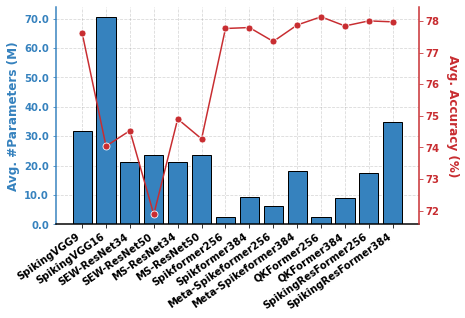

In [10]:
fig, axs = plt.subplots(1, 1, figsize=(6.5, 4))
categories = [
    'SpikingVGG9',
    'SpikingVGG16',
    'SEW-ResNet34',
    'SEW-ResNet50',
    'MS-ResNet34',
    'MS-ResNet50',
    'Spikformer256',
    'Spikformer384',
    'Meta-Spikeformer256',
    'Meta-Spikeformer384',
    'QKFormer256',
    'QKFormer384',
    'SpikingResFormer256',
    'SpikingResFormer384',
]
x = np.arange(len(categories))
axs.set_ylabel('Avg. #Parameters (M)', fontweight='bold', fontsize=12, color='#3682be')
axs.tick_params(
    axis='y',
    colors='#3682be', 
)
axs.spines['left'].set_color('#3682be')

for label in axs.get_xticklabels() + axs.get_yticklabels():
    label.set_fontsize(10)       
    label.set_fontweight('bold')

for spine in axs.spines.values():
    spine.set_linewidth(1.5)

axs.spines['top'].set_visible(False)
axs.spines['right'].set_visible(False)
# axs[i].set_yticks([])
axs.grid(True, which='both', linestyle='--', color='gray', alpha=0.3, zorder=0)
axs.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
axs.set_xticks(x)
axs.set_xticklabels(categories, rotation=35, ha='right')

# define right axis
ax_right = axs.twinx()
for spine in ax_right.spines.values():
    spine.set_linewidth(1.5)
    spine.set_color('#c82d31')
for label in ax_right.get_yticklabels():
    label.set_fontsize(10)       
    label.set_fontweight('bold')
ax_right.spines['top'].set_visible(False)
ax_right.spines['left'].set_visible(False)
ax_right.spines['bottom'].set_visible(False)
ax_right.set_ylabel(f'Avg. Accuracy (%)', fontweight='bold', fontsize=12, rotation=-90, color='#c82d31')
ax_right.tick_params(
    axis='y',
    colors='#c82d31', 
)
ax_right.yaxis.set_label_coords(1.11, 0.5)

# 参数量barplot
params = [
    31.73, 70.44, 21.32, 23.64, 21.32, 23.64, 2.58, 
    9.34, 6.10, 18.23, 2.43, 9.00, 17.35, 34.90
]
axs.bar(
    x, params,
    color='#3682be',
    edgecolor='black', zorder=2)
# avg acc lineplot 
mean_accs = [
    77.62, 74.04, 74.53, 71.88, 74.90, 74.27,
    77.76, 77.79, 77.35, 77.87, 78.13, 77.84, 78.00, 77.97
]
ax_right.plot(
    x, mean_accs, '-o',  linewidth=1.5, markersize=7, markeredgecolor='white',
    color='#c82d31', markeredgewidth=0.8, zorder=2)

# fig.tight_layout()
plt.savefig('./cmp-topology-performance.pdf', dpi=300, bbox_inches="tight")
plt.show()

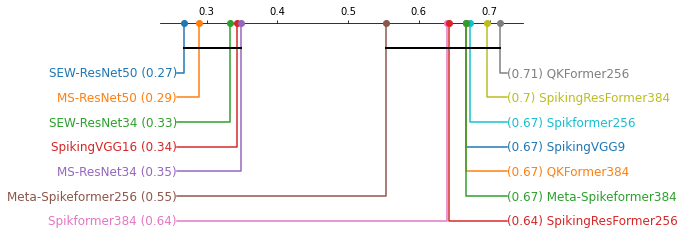

In [11]:
# CD diagram TODO spikformer missing values
fig, axs = plt.subplots(1, 1, figsize=(6.5, 4))
data = pd.read_csv('./topology-res.csv')
avg_rank = data.groupby(
    'dataset_name').accuracy.rank(pct=True).groupby(data.classifier_name).mean()
test_results = sp.posthoc_conover_friedman(
    data, melted=True, block_col='dataset_name', group_col='classifier_name', y_col='accuracy')
sp.critical_difference_diagram(avg_rank, test_results, label_props={'fontsize': 12}, ax=axs)
# fig.tight_layout()
plt.savefig('./cmp-topology-performance-cd.pdf', dpi=300, bbox_inches="tight")
plt.show()

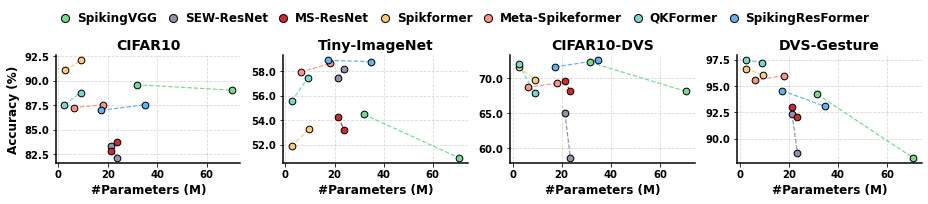

In [9]:
fig, axs = plt.subplots(1, 4, figsize=(13, 2.5))
titles = ['CIFAR10', 'Tiny-ImageNet', 'CIFAR10-DVS', 'DVS-Gesture']
colors = ['#76da91', '#9192ab', '#c82d31', '#f8cb7f', '#f89588', '#7cd6cf', '#63b2ee']
for i in range(4):
    if i == 0:
        axs[i].set_ylabel('Accuracy (%)', fontweight='bold', fontsize=12)

    axs[i].set_title(titles[i], fontweight='bold', fontsize=14)

    for label in axs[i].get_xticklabels() + axs[i].get_yticklabels():
        label.set_fontsize(10)       
        label.set_fontweight('bold')

    for spine in axs[i].spines.values():
        spine.set_linewidth(1.5)
    
    axs[i].spines['top'].set_visible(False)
    axs[i].spines['right'].set_visible(False)
    axs[i].grid(True, which='both', linestyle='--', color='gray', alpha=0.3, zorder=0)
    axs[i].yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
    axs[i].set_xlabel('#Parameters (M)', fontweight='bold', fontsize=12)


# cifar10
res_dict = {
    'SpikingVGG': {
        'acc': [89.58, 89.02],
        'param': [31.61, 70.32],
    },
    'SEW-ResNet': {
        'acc': [83.37, 82.11],
        'param': [21.29, 23.53],
    },
    'MS-ResNet': {
        'acc': [82.79, 83.73],
        'param': [21.29, 23.53],
    },
    'Spikformer': {
        'acc': [91.04, 92.07],
        'param': [2.57, 9.32],
    },
    'Meta-Spikeformer': {
        'acc': [87.24, 87.55],
        'param': [6.09, 18.20],
    },
    'QKFormer': {
        'acc': [87.54, 88.77],
        'param': [2.42, 8.98],
    },
    'SpikingResFormer': {
        'acc': [86.97, 87.53],
        'param': [17.32, 34.86],
    },
}
for idx, (m, res) in enumerate(res_dict.items()):
    axs[0].plot(res['param'], res['acc'], linestyle='--', color=colors[idx], linewidth=1.2, zorder=2)
    axs[0].scatter(res['param'], res['acc'], label=m, color=colors[idx], s=45, edgecolors='black', zorder=3)

# tiny-imagenet
res_dict = {
    'SpikingVGG': {
        'acc': [54.47, 50.92],
        'param': [32, 70.71],
    },
    'SEW-ResNet': {
        'acc': [57.43, 58.21],
        'param': [21.39, 23.92],
    },
    'MS-ResNet': {
        'acc': [54.26, 53.22],
        'param': [21.39, 23.92],
    },
    'Spikformer': {
        'acc': [51.86, 53.29],
        'param': [2.62, 9.40],
    },
    'Meta-Spikeformer': {
        'acc': [57.93, 58.63],
        'param': [6.15, 18.29],
    },
    'QKFormer': {
        'acc': [55.53, 57.45],
        'param': [2.46, 9.05],
    },
    'SpikingResFormer': {
        'acc': [58.89, 58.77],
        'param': [17.42, 35.00],
    },
}
for idx, (m, res) in enumerate(res_dict.items()):
    axs[1].plot(res['param'], res['acc'], linestyle='--', color=colors[idx], linewidth=1.2, zorder=2)
    axs[1].scatter(res['param'], res['acc'], color=colors[idx], s=45, edgecolors='black', zorder=3)

# cifar10-dvs
res_dict = {
    'SpikingVGG': {
        'acc': [72.23, 68.08],
        'param': [31.61, 70.71],
    },
    'SEW-ResNet': {
        'acc': [64.99, 58.58],
        'param': [21.29, 23.53],
    },
    'MS-ResNet': {
        'acc': [69.52, 68.11],
        'param': [21.29, 23.53],
    },
    'Spikformer': {
        'acc': [71.52, 69.72],
        'param': [2.57, 9.32],
    },
    'Meta-Spikeformer': {
        'acc': [68.65, 69.29],
        'param': [6.08, 18.20],
    },
    'QKFormer': {
        'acc': [71.98, 67.90],
        'param': [2.42, 8.98],
    },
    'SpikingResFormer': {
        'acc': [71.58, 72.53],
        'param': [17.32, 34.85],
    },
}
for idx, (m, res) in enumerate(res_dict.items()):
    axs[2].plot(res['param'], res['acc'], linestyle='--', color=colors[idx], linewidth=1.2, zorder=2)
    axs[2].scatter(res['param'], res['acc'], color=colors[idx], s=45, edgecolors='black', zorder=3)

# dvs-gesture
res_dict = {
    'SpikingVGG': {
        'acc': [94.21, 88.16],
        'param': [31.61, 70.71],
    },
    'SEW-ResNet': {
        'acc': [92.36, 88.66],
        'param': [21.29, 23.53],
    },
    'MS-ResNet': {
        'acc': [93.05, 92.02],
        'param': [21.29, 23.53],
    },
    'Spikformer': {
        'acc': [96.64, 96.07],
        'param': [2.57, 9.32],
    },
    'Meta-Spikeformer': {
        'acc': [95.55, 95.99],
        'param': [6.08, 18.20],
    },
    'QKFormer': {
        'acc': [97.45, 97.22],
        'param': [2.42, 8.98],
    },
    'SpikingResFormer': {
        'acc': [94.56, 93.06],
        'param': [17.32, 34.85],
    },
}
for idx, (m, res) in enumerate(res_dict.items()):
    axs[3].plot(res['param'], res['acc'], linestyle='--', color=colors[idx], linewidth=1.2, zorder=2)
    axs[3].scatter(res['param'], res['acc'], color=colors[idx], s=45, edgecolors='black', zorder=3)

fig.legend(
    # categories, 
    loc='upper center', 
    bbox_to_anchor=(0.5, 1.15), 
    ncol=7, 
    handlelength=1,  
    handletextpad=0.5, 
    columnspacing=.8, 
    markerscale=1.2,
    prop={'weight': 'bold', 'size': 12},
    frameon=False,
)

fig.tight_layout()
plt.savefig('./cmp-topology.pdf', dpi=300, bbox_inches="tight")
plt.show()